<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/week6_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM FILTER

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [3]:
# --- Fungsi Konvolusi 2D (grayscale) ---
def convolution2d(image, kernel, stride, padding):
    # 1. Menyiapkan variabel dimensi
    h_img, w_img = image.shape
    h_ker, w_ker = kernel.shape

    # 2. Menghitung dimensi output
    h_out = int(((h_img - h_ker + 2 * padding) / stride) + 1)
    w_out = int(((w_img - w_ker + 2 * padding) / stride) + 1)

    # 3. Menambahkan padding
    if padding > 0:
        padded_image = np.zeros((h_img + 2 * padding, w_img + 2 * padding))
        padded_image[padding:-padding, padding:-padding] = image
    else:
        padded_image = image

    # 4. Membuat matriks output
    output = np.zeros((h_out, w_out))

    # 5. Proses konvolusi
    for y in range(h_out):
        for x in range(w_out):
            y_start, y_end = y * stride, y * stride + h_ker
            x_start, x_end = x * stride, x * stride + w_ker
            image_slice = padded_image[y_start:y_end, x_start:x_end]
            output[y, x] = np.sum(image_slice * kernel)

    return output

Sharpen

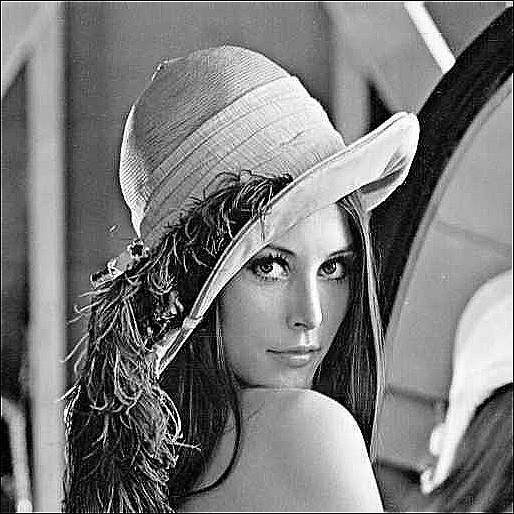

In [ ]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Emboss

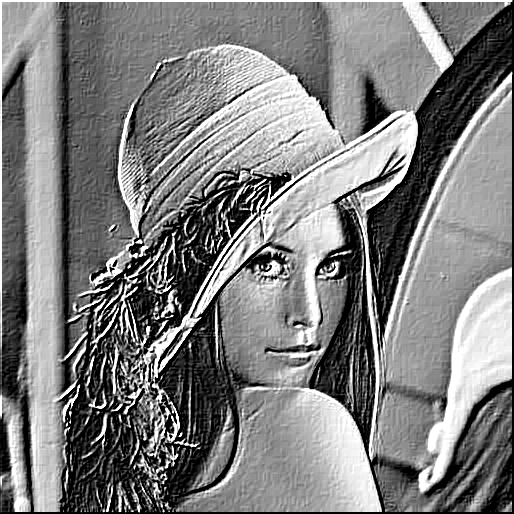

In [ ]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_emboss = np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_emboss, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Left Sobel Edge Detection

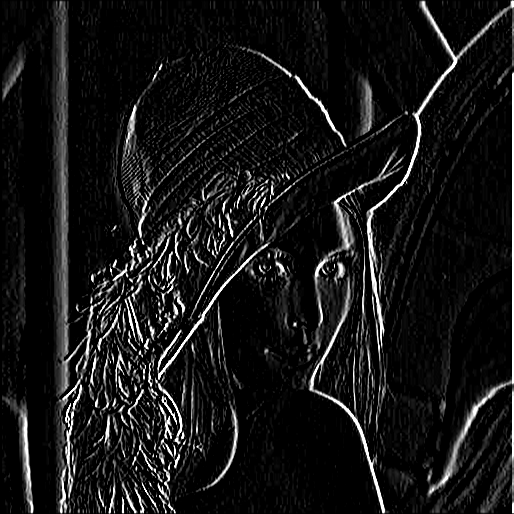

In [ ]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_lsed = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_lsed, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

Canny Edge Detection

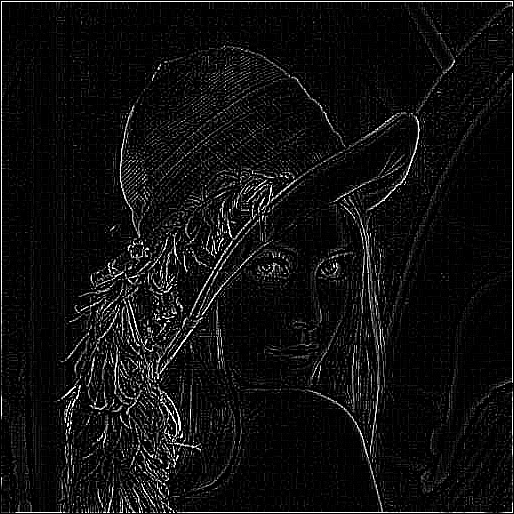

In [ ]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_canny = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]])

# memanggil fungsi konvolusi
output = convolution2d(img_gray, kernel_canny, stride=1, padding=2)

# menampilkan hasil
cv2_imshow(output)

21x21 Gaussian Blur

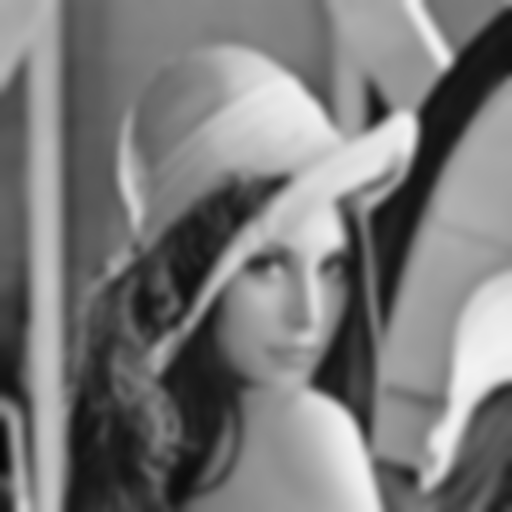

In [40]:
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_size = 21 # Define kernel_size here as it's used later
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Apply the 2D Gaussian kernel using filter2D
blurred = cv.filter2D(img_gray, -1, gauss_kernel)

# Display the result
cv2_imshow(blurred)

# E. FILTER LIBRARY DAN FILTER MODERN

Percobaan 1

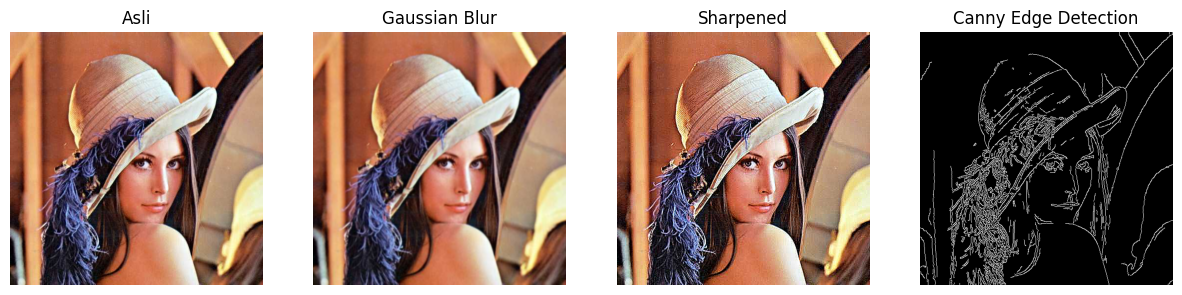

In [8]:
#Fungsi tampil berdampingan
def show_side_by_side(images,titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2: #grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else: # color
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ['Asli', 'Gaussian Blur', 'Sharpened', 'Canny Edge Detection'])

Percobaan 2

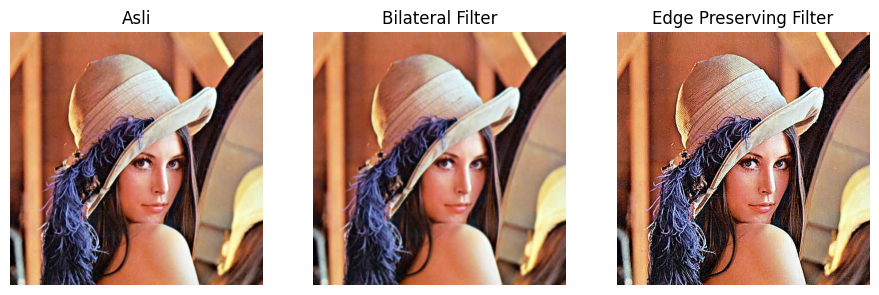

In [9]:
#Filter Modern dari OpenCV
#Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

#Edge Preserving Filter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, blur, sharpened, edges],
                  ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

Percobaan 3

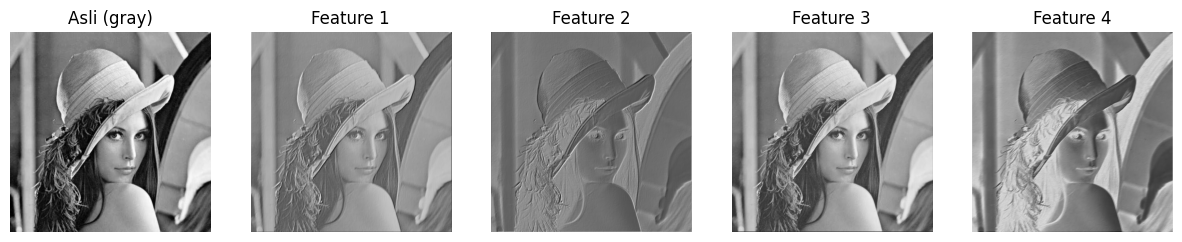

In [21]:
# filter feature map pada CNN
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
      return self.conv1(x)

model = SimpleCNN()

# ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

#hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# visualisasi
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Asli (gray)'] + [f'Feature {i+1}' for i in range(len(feature_maps))])

Percobaan 4

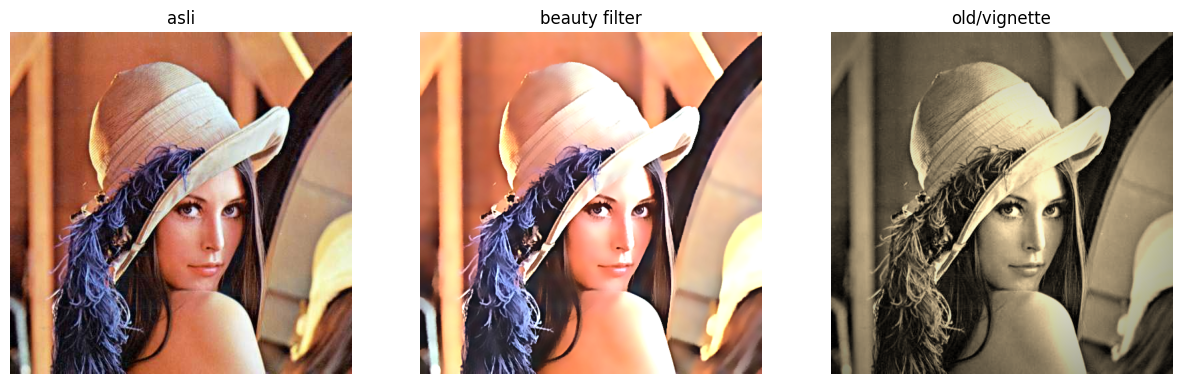

In [26]:
# ========================
# 1. Beauty Filter
# ========================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (mempertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
# Menggunakan convertScaleAbs() untuk menyesuaikan kecerahan dan kontras.
alpha = 1.2  # Kontras
beta = 15    # Kecerahan
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =========================
# 2. Old/Vintage Filter
# =========================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, vignette], ["asli", "beauty filter", "old/vignette"])

Percobaan 5

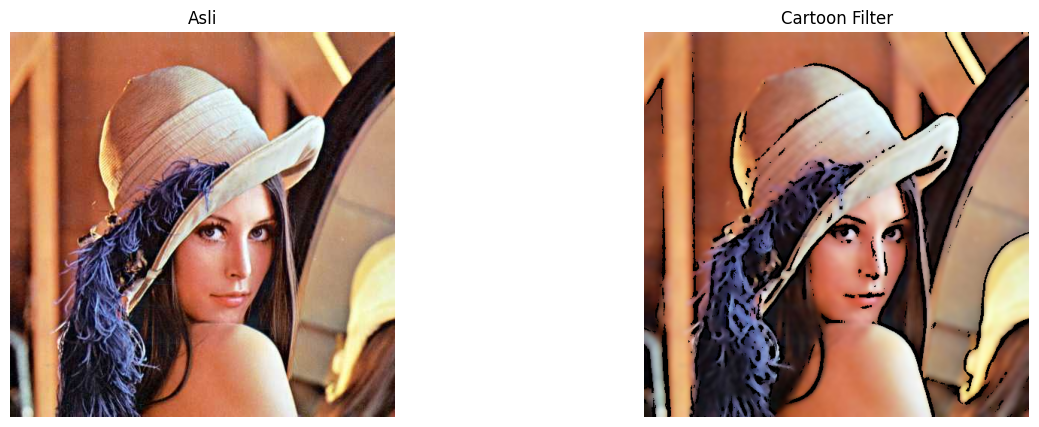

In [28]:
# Filter Anime / Kartun
# Step 1: Deteksi Tepi (Edge Detection)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                            cv.ADAPTIVE_THRESH_MEAN_C,
                            cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (Cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6

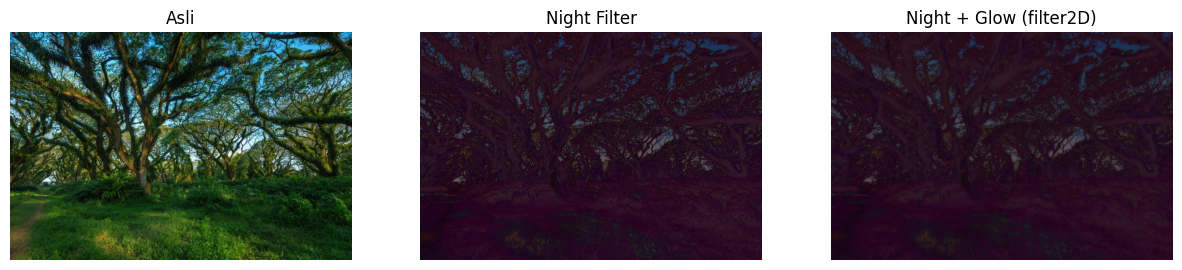

In [41]:
#Night filter
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: gelapkan(contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

#step 2: tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) #BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# step 3:efek glow di area terang dengan filter2D (blue kernel)
kernel = np.ones((15,15), np.float32) / 255
glow = cv.filter2D(night, -1, kernel)

# kombinasi asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# tampilkan
show_side_by_side([img, night , night_glow],
                  ["Asli", "Night Filter", 'Night + Glow (filter2D)'])

Percobaan 7

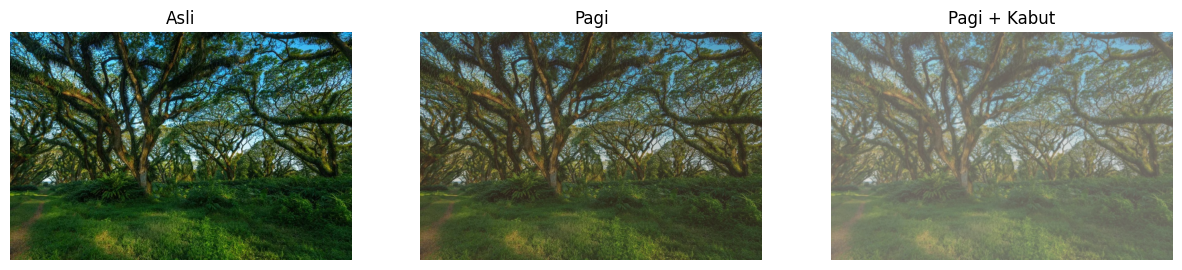

In [42]:
# Filter Suasana Pagi dan Kabut
# ================================

# Step 1: Kurangi kontras & cerahkan
alpha = 0.9 # Kontras
beta = 20  # Kecerahan
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# kernel blur gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah Layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

# Menampilkan hasil
show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])